In [1]:

from imblearn.over_sampling import SMOTE
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from google.colab import drive

In [2]:

from google.colab import drive
drive.mount('/content/drive')

Directory = "/content/drive/MyDrive/sickle cell uganda 2024/sickle cell uganda 2024"
Categories = ['Negative','Positive']

print(f"Directory: {Directory}")
print(f"Categories: {Categories}")

Mounted at /content/drive
Directory: /content/drive/MyDrive/sickle cell uganda 2024/sickle cell uganda 2024
Categories: ['Negative', 'Positive']


In [3]:

def print_directory_structure(directory):
    print(f"Contents of {directory}:")
    for category in os.listdir(directory):
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            print(f"  {category}/ (Directory)")
            for subfolder in os.listdir(category_path):
                subfolder_path = os.path.join(category_path, subfolder)
                if os.path.isdir(subfolder_path):
                    print(f"    {subfolder}/ (Subfolder)")
                    for file in os.listdir(subfolder_path):
                        print(f"      {file}")

print_directory_structure(Directory)

Contents of /content/drive/MyDrive/sickle cell uganda 2024/sickle cell uganda 2024:
  Negative/ (Directory)
    Clear/ (Subfolder)
      103.jpg
      101.jpg
      102.jpg
      107.jpg
      10.jpg
      1.jpg
      105.jpg
      100.jpg
      106.jpg
      104.jpg
      114.jpg
      115.jpg
      108.jpg
      112.jpg
      110.jpg
      113.jpg
      11.jpg
      109.jpg
      111.jpg
      119.jpg
      118.jpg
      12.jpg
      120.jpg
      121.jpg
      117.jpg
      116.jpg
      124.jpg
      127.jpg
      128.jpg
      122.jpg
      123.jpg
      126.jpg
      125.jpg
      13.jpg
      129.jpg
      133.jpg
      134.jpg
      132.jpg
      131.jpg
      130.jpg
      139.jpg
      137.jpg
      135.jpg
      14.jpg
      140.jpg
      138.jpg
      136.jpg
      147.jpg
      145.jpg
      144.jpg
      142.jpg
      141.jpg
      143.jpg
      146.jpg
      19.jpg
      16.jpg
      2.jpg
      17.jpg
      15.jpg
      18.jpg
      24.jpg
      21.jpg
      20.jpg
    

In [4]:
def load_data(directory, categories):
    data = []
    labels = []
    for category in categories:
        category_path = os.path.join(directory, category)
        if not os.path.isdir(category_path):
            print(f"Warning: {category} is not a directory in {directory}")
            continue

        class_num = categories.index(category)

        # Define subfolders based on the category
        if category == 'Negative':
            subfolders = ['Clear']
        elif category == 'Positive':
            subfolders = ['Unlabelled', 'Labelled']
        else:
            print(f"Warning: Unknown category {category}")
            continue

        for subfolder in subfolders:
            subfolder_path = os.path.join(category_path, subfolder)
            if not os.path.isdir(subfolder_path):
                print(f"Warning: {subfolder} not found in {category_path}")
                continue

            for img_name in os.listdir(subfolder_path):
                img_path = os.path.join(subfolder_path, img_name)
                try:
                    img_array = cv2.imread(img_path)
                    if img_array is None:
                        print(f"Error: Unable to read image {img_path}")
                        continue
                    if img_array.size == 0:
                        print(f"Error: Empty image {img_path}")
                        continue
                    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
                    resized_array = cv2.resize(img_array, (100, 100))
                    data.append(resized_array)
                    labels.append(class_num)
                except Exception as e:
                    print(f"Error processing image {img_path}: {str(e)}")

    if not data:
        print("No valid images found in the specified directories.")
        return np.array([]), np.array([])

    return np.array(data), np.array(labels)

In [5]:
# Test the function
Categories = ['Negative', 'Positive']
data, labels = load_data(Directory, Categories)
print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")

Data shape: (991, 100, 100)
Labels shape: (991,)


In [6]:
# Normalize and reshape the data
data = data / 255.0
data = data.reshape(-1, 100*100)  # Flatten the images for SMOTE

In [7]:
# Apply SMOTE
smote = SMOTE(random_state=42)
data_resampled, labels_resampled = smote.fit_resample(data, labels)

In [8]:

# Reshape back to image format
data_resampled = data_resampled.reshape(-1, 100, 100, 1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(data_resampled, labels_resampled, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1350, 100, 100, 1)
Testing data shape: (338, 100, 100, 1)


In [9]:

import tensorflow as tf

def create_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [10]:

# Create and summarize the model
model = create_model()
model.summary()

# Train the model
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(X_test, y_test))

# Save the model
model.save('sickle_cell_model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 98, 98, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 47, 47, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 21, 21, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         409,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 465,473 (1.78 MB)

 Trainable params: 465,473 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.5426 - loss: 0.6923 - val_accuracy: 0.6775 - val_loss: 0.6064
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7197 - loss: 0.5619 - val_accuracy: 0.7278 - val_loss: 0.5007
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7803 - loss: 0.4672 - val_accuracy: 0.7722 - val_loss: 0.4434
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7629 - loss: 0.4605 - val_accuracy: 0.7751 - val_loss: 0.4690
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7731 - loss: 0.4625 - val_accuracy: 0.7781 - val_loss: 0.4437
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7846 - loss: 0.4414 - val_accuracy: 0.7781 - val_loss: 0.4286
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8055 - loss: 0.4145 - val_accuracy: 0.7781 - val_loss: 0.4365
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7801 - loss: 0.4276 - val_accuracy: 0.7988 - va

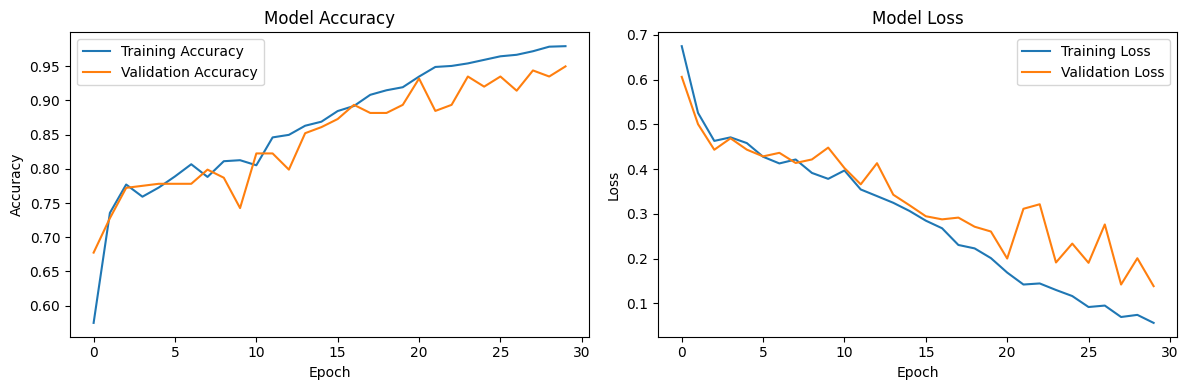

In [11]:

import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
image_path = '/content/drive/MyDrive/sickle cell uganda 2024/sickle cell uganda 2024/Negative/Clear/1.jpg'
def predict_sickle_cell(model, image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (100, 100))
    img = img / 255.0
    img = img.reshape(-1, 100, 100, 1)

    prediction = model.predict(img)

    if prediction[0][0] > 0.5:
        return "Positive", prediction[0][0]
    else:
        return "Negative", 1 - prediction[0][0]

result, confidence = predict_sickle_cell(model, image_path)
print(f"Prediction: {result}")
print(f"Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step
Prediction: Negative
Confidence: 0.97


In [13]:
# Importing necessary libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [14]:
# Flatten the images for traditional ML models
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [15]:


# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

In [16]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9112426035502958
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       156
           1       0.92      0.92      0.92       182

    accuracy                           0.91       338
   macro avg       0.91      0.91      0.91       338
weighted avg       0.91      0.91      0.91       338



In [24]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=30, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("\nRandom Forest Accuracy:", rf_accuracy)
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.9674556213017751
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       156
           1       0.98      0.96      0.97       182

    accuracy                           0.97       338
   macro avg       0.97      0.97      0.97       338
weighted avg       0.97      0.97      0.97       338



In [30]:
# SVm
svm_model = SVC(kernel='rbf', random_state=30)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)
print("\nSVM Accuracy:", svm_accuracy)
print("SVM Classification Report:")
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.9704142011834319
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       156
           1       0.99      0.96      0.97       182

    accuracy                           0.97       338
   macro avg       0.97      0.97      0.97       338
weighted avg       0.97      0.97      0.97       338



In [19]:
# Compare with CNN model
cnn_pred = (model.predict(X_test) > 0.5).astype(int)
cnn_accuracy = accuracy_score(y_test, cnn_pred)
print("\nCNN Model Accuracy:", cnn_accuracy)
print("CNN Model Classification Report:")
print(classification_report(y_test, cnn_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

CNN Model Accuracy: 0.9497041420118343
CNN Model Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       156
           1       0.95      0.96      0.95       182

    accuracy                           0.95       338
   macro avg       0.95      0.95      0.95       338
weighted avg       0.95      0.95      0.95       338



In [27]:
# TensorFlow CNN model (your existing model)
tf_pred = (model.predict(X_train) > 0.5).astype(int)
tf_accuracy = accuracy_score(y_train, tf_pred)
print("\nTensorFlow CNN Model Accuracy:", tf_accuracy)
print("TensorFlow CNN Model Classification Report:")
print(classification_report(y_train, tf_pred))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

TensorFlow CNN Model Accuracy: 0.9918518518518519
TensorFlow CNN Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       688
           1       0.99      1.00      0.99       662

    accuracy                           0.99      1350
   macro avg       0.99      0.99      0.99      1350
weighted avg       0.99      0.99      0.99      1350



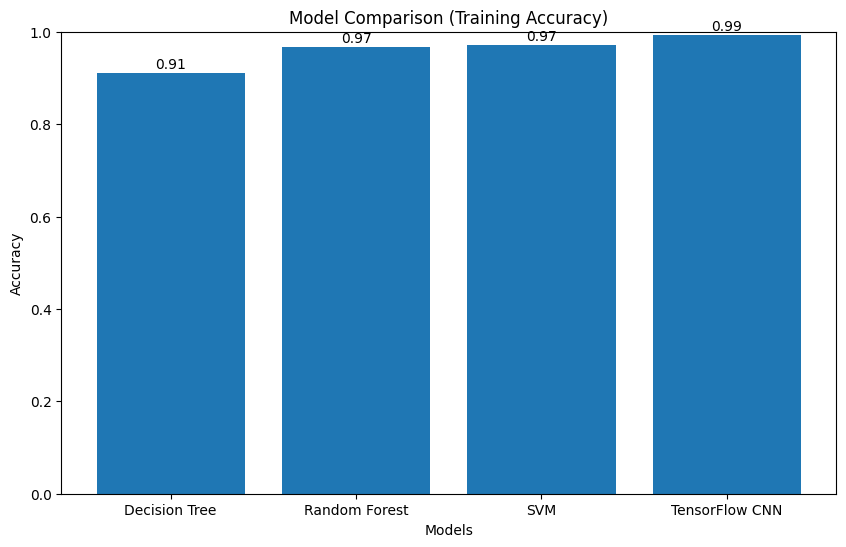

In [31]:
# Visualize results
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Random Forest', 'SVM', 'TensorFlow CNN']
accuracies = [dt_accuracy, rf_accuracy, svm_accuracy, tf_accuracy]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies)
plt.title('Model Comparison (Training Accuracy)')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.show()